<a id="introduction"></a>

# Problem Set 5 (PS5): Let's Play with an Autoencoder

Grayscale fashion images from the [FashionMNIST dataset](https://github.com/zalandoresearch/fashion-mnist) contain rich spatial structure that varies across item styles yet remains recognizable as the same clothing category. In this problem set, we build and train a deterministic **Autoencoder (AE)** that learns to compress each 4096-pixel image into a low-dimensional **bottleneck code** and then reconstruct it from that code alone.

The autoencoder is a direct neural-network analogue of the embedding models you built in the previous problem set. In CBOW and Skip-Gram, a weight matrix $\mathbf{W}_1$ maps a sparse one-hot word vector into a dense embedding, and $\mathbf{W}_2$ decodes that embedding back into a prediction. An autoencoder does the same thing for images, but with deeper non-linear encoder and decoder networks and reconstruction error as the training signal instead of cross-entropy.

> __Learning Objectives__
 >
 > By the end of this problem set, you should be able to:
 > * __Implement an encoder and decoder using Flux.jl:__ Write `encode` and `decode` functions that map inputs to a low-dimensional bottleneck and back, using [`Chain`](https://fluxml.ai/Flux.jl/stable/models/layers/#Flux.Chain) and [`Dense`](https://fluxml.ai/Flux.jl/stable/models/layers/#Flux.Dense) layers with ReLU and sigmoid activations.
 > * __Implement and minimize a reconstruction loss:__ Compute mean-squared error between the input and its reconstruction, and write a Flux.jl training loop that minimizes it using the Adam optimizer.
 > * __Visualize and interpret the learned latent space:__ Encode images to their bottleneck codes, decode them back, and linearly interpolate between two codes to test whether the AE has learned a smooth latent geometry.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading the
FashionMNIST dataset, and setting up the required constants.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of `Include.jl` in the notebook's global scope. `Include.jl` sets paths, loads required external packages, and includes `src/Types.jl` and `src/Compute.jl`, which define the `MyAEModel` type and the helper functions used throughout this notebook.

Let's load the environment.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we use [Flux.jl](https://fluxml.ai/Flux.jl/stable/) for automatic differentiation and neural network layers, [MLDatasets.jl](https://juliaml.github.io/MLDatasets.jl/stable/) to load FashionMNIST, and [Plots.jl](https://docs.juliaplots.org/stable/) for visualization. `Include.jl` loads these packages and includes `src/Types.jl` (defines `MyAEModel`) and `src/Compute.jl` (defines helper functions).

### Implementations
Complete the three functions below for this problem set.

> __Helper functions (provided in [`src/Compute.jl`](src/Compute.jl))__
>
> * [`build_ae_model(input_dim, hidden_dim, latent_dim)`](src/Compute.jl): Constructs a `MyAEModel` with a symmetric encoder-decoder architecture.
> * [`load_fashion_class(class; n_examples)`](src/Compute.jl): Loads FashionMNIST training images for one class, upscales to 64x64, and returns a $(4096 \times N)$ Float32 matrix with pixel values in $[0, 1]$.
> * [`show_image_grid(X; nrows, ncols, titles)`](src/Compute.jl): Displays columns of a $4096 \times N$ matrix as a grid of 64x64 grayscale images with optional per-image titles.

In addition, complete the three functions below that are the core of the autoencoder forward pass. `encode` maps inputs to bottleneck codes via `model.encoder`, `decode` reconstructs inputs from codes via `model.decoder`, and `reconstruction_loss` composes both to compute the mean-squared reconstruction error.

In [2]:
# Task 1a: encode
# --------------------------------------------------------------------------
# encode maps a batch of inputs x (D × N) to bottleneck codes z (L × N).
#
# Steps:
#   1. Pass x through model.encoder
#   2. Return the result

function encode(model::MyAEModel, x::AbstractMatrix)
    # YOUR CODE HERE
    return model.encoder(x)
end

# Task 1b: decode
# --------------------------------------------------------------------------
# decode maps bottleneck codes z (L × N) to reconstructed inputs x̂ (D × N).
#
# Steps:
#   1. Pass z through model.decoder
#   2. Return the result
#      (the final sigmoid layer already constrains output to [0, 1])

function decode(model::MyAEModel, z::AbstractMatrix)
    # YOUR CODE HERE
    return model.decoder(z)
end

# Task 2a: reconstruction_loss
# --------------------------------------------------------------------------
# reconstruction_loss should:
#   1. Encode x  →  z   using encode(model, x)
#   2. Decode z  →  x̂  using decode(model, z)
#   3. Return the MSE:  mean(sum((x .- x̂).^2; dims=1))

function reconstruction_loss(model::MyAEModel, x::AbstractMatrix)
    # YOUR CODE HERE
    z = encode(model,x)
    x̂ = decode(model,z)
    return mean(sum((x .- x̂).^2; dims=1))
end

reconstruction_loss (generic function with 1 method)

### Constants

With the three functions defined, let's set the constants that control the dataset, model architecture, and training schedule. The comment next to each constant describes its purpose and permissible values.

In [3]:
# constants -
CLASS, K, D, L, H, LR, NUM_EPOCHS = let
    CLASS       = 3;       # FashionMNIST class to model (0-9); 3 = Dress
    K           = 100;     # number of training examples
    D           = 4096;    # input dimension: 64 x 64 = 4096 pixels
    L           = 8;       # bottleneck (latent) dimension
    H           = 512;     # hidden-layer width
    LR          = 1f-3;    # Adam learning rate
    NUM_EPOCHS  = 2_000;   # training epochs

    (CLASS, K, D, L, H, LR, NUM_EPOCHS)
end;
Random.seed!(42);

### Background: Autoencoders

An autoencoder is a neural network trained to reproduce its own input at the output layer,
subject to passing through a low-dimensional **bottleneck**. It consists of two sub-networks:

| Component | Maps | Role |
|-----------|------|------|
| **Encoder** $f_\theta$ | $\mathbf{x}\in\mathbb{R}^D \to \mathbf{z}\in\mathbb{R}^L,\; L\ll D$ | compresses input to a compact code |
| **Decoder** $g_\phi$ | $\mathbf{z}\in\mathbb{R}^L \to \hat{\mathbf{x}}\in\mathbb{R}^D$ | reconstructs the input from the code |

Both are trained jointly to minimize the **reconstruction loss** over the training set:

$$\mathcal{L}(\theta,\phi) = \frac{1}{N}\sum_{i=1}^{N}\|\mathbf{x}_i - g_\phi(f_\theta(\mathbf{x}_i))\|_2^2$$

Because the only path from input to output passes through the $L$-dimensional bottleneck,
the encoder is forced to retain only the most important structure of the data, and the
decoder must learn to recover the full input from that compressed representation.

### Data Loading and Exploration
We train the autoencoder on $K = 100$ examples of FashionMNIST class **3 (Dress)** from the training split. Each 64x64 grayscale image is flattened to a 4096-dimensional vector and stored as a column of the data matrix $\mathbf{X} \in \mathbb{R}^{4096 \times K}$, with pixel values in $[0, 1]$.

> __[`load_fashion_class(CLASS; n_examples = K)`](src/Compute.jl)__
>
> Queries `MLDatasets.FashionMNIST(:train)` for all images of class `CLASS`, selects the first `K`, flattens each 64x64 array to a 4096-element column vector, and returns a `(4096 x K)` Float32 matrix. Pixel values are already normalized to $[0, 1]$ by MLDatasets.

Let's load the data, compute pixel statistics, and visualize a sample grid.

In [4]:
# load the data -
X = let
    # YOUR CODE HERE: call load_fashion_class with CLASS and K
    X = load_fashion_class(CLASS; n_examples=K);

    println("Data matrix size: $(size(X))")  # expected: (4096, 100)
    X # return
end;

Data matrix size: (4096, 100)


With the data loaded, let's characterize the pixel value distribution of the training set.

> __Pixel statistics__
>
> The mean pixel value of FashionMNIST images is well below 0.5 because most pixels are dark background. This explains why the initial reconstruction loss is large: the decoder must learn to reproduce many near-zero pixels.

Let's compute the mean and standard deviation of all pixel values in `X`.

In [6]:
# pixel statistics -
μ_data, σ_data = let
    # YOUR CODE HERE: compute mean and std of all pixel values in X
    μ_data = mean(X);
    σ_data = std(X);

    @printf("Mean pixel value: %.4f\n", μ_data);
    @printf("Std  pixel value: %.4f\n", σ_data);
    (μ_data, σ_data) # return
end;

Mean pixel value: 0.2808
Std  pixel value: 0.3530


In [7]:
# ── Autograder: Setup ────────────────────────────────────────────────────────
check!(GRADER, "Setup", "X loaded, shape (4096, 100)",   1, () -> !ismissing(X) && size(X) == (D, K))
check!(GRADER, "Setup", "μ_data ≈ mean pixel value",    1, () -> !ismissing(μ_data) && μ_data ≈ mean(X))
check!(GRADER, "Setup", "σ_data ≈ std pixel value",     1, () -> !ismissing(σ_data) && σ_data ≈ std(X))

  ✓   1 /  1 pts  X loaded, shape (4096, 100)
  ✓   1 /  1 pts  μ_data ≈ mean pixel value
  ✓   1 /  1 pts  σ_data ≈ std pixel value


What do we observe?

> __Visualizing the training data__
>
> Before building the model, let's look at a sample of the fashion images we are working with. [`show_image_grid`](src/Compute.jl) reshapes each 4096-element column of `X` back to a 64x64 array and renders it as a grayscale heatmap, so we can verify the data loaded correctly and get an intuition for the variation in style across examples.

Let's display a 4x4 grid of training examples to see what we're working with.

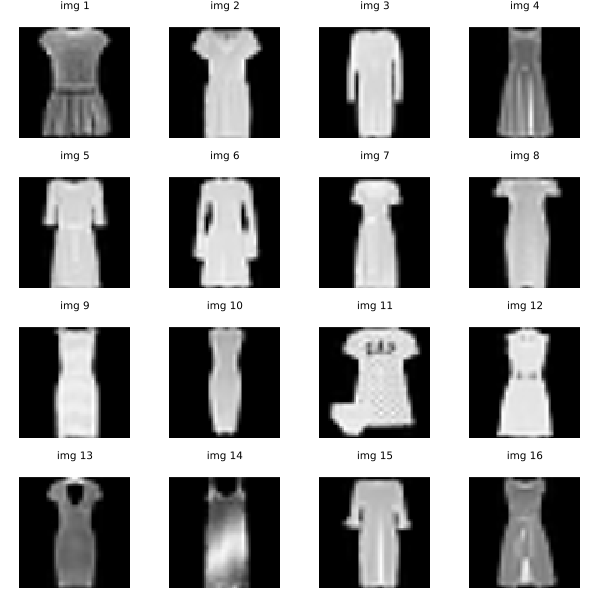

In [8]:
# visualize training examples -
let
    titles = ["img $(i)" for i in 1:16];  # label each image in the grid
    show_image_grid(X; nrows=4, ncols=4, titles=titles)
end

___
## Task 1: Autoencoder Architecture

The autoencoder forward pass requires two operations. The **encoder** compresses each $D = 4096$-pixel input to an $L = 8$-dimensional bottleneck code, and the **decoder** reconstructs the input from that code alone. Both are one-line wrappers around the [`Chain`](https://fluxml.ai/Flux.jl/stable/models/layers/#Flux.Chain) objects stored in `model.encoder` and `model.decoder`, which were defined earlier in the notebook.

> __What is going on in this code block?__
>
> [`build_ae_model(D, H, L)`](src/Compute.jl) (in `src/Compute.jl`) constructs a `MyAEModel` with a
> symmetric architecture. The encoder compresses $4096\to512\to256\to L=8$ using ReLU
> activations, with **no activation on the bottleneck** so that codes are unconstrained
> real numbers. The decoder inverts this path ($8\to256\to512\to4096$) and ends with a
> **sigmoid** that constrains reconstructions to $[0,1]$, matching the normalized pixel range.

Let's build the model and inspect its architecture.

In [9]:
# build the autoencoder -
ae = let
    # construct encoder (D->H->H/2->L) and decoder (L->H/2->H->D) -
    ae = build_ae_model(D, H, L);

    # report architecture and parameter count -
    n_params = sum(length, Flux.trainable(ae));
    println("Encoder: $(D) → $(H) → $(H÷2) → $(L)");
    println("Decoder: $(L) → $(H÷2) → $(H) → $(D)");
    println("Total parameters: $(n_params)");
    ae # return
end;

Encoder: 4096 → 512 → 256 → 8
Decoder: 8 → 256 → 512 → 4096
Total parameters: 6


The autograder checks that `encode` returns an $(L \times N)$ matrix with no `NaN` values and that `decode` returns a $(D \times N)$ matrix with all values in $[0, 1]$.

In [10]:
# ── Autograder: Task 1 ──────────────────────────────────────────────────────
let
    x_test = X[:, 1:5]
    z_test = encode(ae, x_test)
    x̂_test = decode(ae, z_test)

    check!(GRADER, "Task 1", "encode: output shape is (L, N)",   1, () -> size(z_test) == (L, 5))
    check!(GRADER, "Task 1", "encode: output has no NaN",        1, () -> !any(isnan, z_test))
    check!(GRADER, "Task 1", "decode: output shape is (D, N)",   1, () -> size(x̂_test) == (D, 5))
    check!(GRADER, "Task 1", "decode: output in [0, 1]",         1, () -> all(0f0 .≤ x̂_test .≤ 1f0))
end

  ✓   1 /  1 pts  encode: output shape is (L, N)
  ✓   1 /  1 pts  encode: output has no NaN
  ✓   1 /  1 pts  decode: output shape is (D, N)
  ✓   1 /  1 pts  decode: output in [0, 1]


The autograder verifies that `reconstruction_loss` returns a positive scalar less than $D$, confirming the forward pass composes correctly.

___
## Task 2: Reconstruction Loss and Training

With the encoder and decoder in place, we can define the training objective and run the optimization loop. The reconstruction loss measures how well the autoencoder recovers each input after passing through the bottleneck, and Adam updates all encoder and decoder parameters to reduce that loss.

The `reconstruction_loss(...)` function is defined in the Implementations section above. It implements the mean-squared reconstruction loss given by:

$$\mathcal{L}(\theta,\phi) = \frac{1}{N}\sum_{i=1}^{N}\|\mathbf{x}_i - \hat{\mathbf{x}}_i\|_2^2 = \texttt{mean}(\texttt{sum}((\mathbf{X} - \hat{\mathbf{X}})^{\odot 2};\,\text{dims}=1))$$

Let's verify the loss on a small sample and then run the training loop.

In [11]:
# ── Autograder: Task 2a ─────────────────────────────────────────────────────
let
    x_test = X[:, 1:5]
    loss   = reconstruction_loss(ae, x_test)

    check!(GRADER, "Task 2", "loss is a scalar Float",   1, () -> loss isa AbstractFloat)
    check!(GRADER, "Task 2", "loss is positive",          1, () -> loss > 0)
    check!(GRADER, "Task 2", "loss < D (sanity bound)",   1, () -> loss < D)
end

  ✓   1 /  1 pts  loss is a scalar Float
  ✓   1 /  1 pts  loss is positive
  ✓   1 /  1 pts  loss < D (sanity bound)


With the forward pass verified, let's set up the optimizer and run the training loop.

> __Training with [`Flux.withgradient`](https://fluxml.ai/Flux.jl/stable/training/reference/#Flux.withgradient) and [`Flux.update!`](https://fluxml.ai/Flux.jl/stable/training/reference/#Flux.update!)__
>
> `Flux.withgradient(ae) do m ... end` returns both the scalar loss and a gradient tuple in a single forward-backward pass. Inside the `do` block, `m` is a differentiable handle to `ae`. Calling `reconstruction_loss(m, X)` there lets Flux trace gradients through the full encode-decode chain. [`Flux.update!`](https://fluxml.ai/Flux.jl/stable/training/reference/#Flux.update!) then applies the Adam step to every parameter at once. If a pre-trained model exists on disk, we load it instead of retraining.

Let's train the autoencoder for `NUM_EPOCHS = 2000` epochs and store the per-epoch loss in `losses`.

In [13]:
# train the autoencoder (or load a pre-trained model) -
ae, losses = let

    # path where we save/load trained model weights -
    model_path = joinpath(_PATH_TO_DATA, "ae_class$(CLASS)_L$(L).jld2");
    losses = Float32[];

    if isfile(model_path) == true

        # we have a pre-trained model on disk, load it -
        println("Loading pre-trained model from $(model_path)");
        f = jldopen(model_path, "r");
        model_state = f["model_state"]; losses = f["losses"];
        close(f);
        Flux.loadmodel!(ae, model_state);
        println("Model loaded. Final loss: $(round(losses[end], digits=4))");
    else

        # no saved model found, train from scratch -
        opt_state = Flux.setup(Adam(LR), ae);
        println("Training autoencoder...");
        for epoch in 1:NUM_EPOCHS

            # forward pass + gradient computation in one call -
            loss, grads = Flux.withgradient(ae) do m
                # YOUR CODE HERE: one line, call reconstruction_loss on the full dataset X
                reconstruction_loss(m,X)
            end;

            Flux.update!(opt_state, ae, grads[1]);  # apply the Adam step
            push!(losses, loss);                     # record this epoch's loss
            epoch % 400 == 0 && @printf("  Epoch %4d | loss = %.4f\n", epoch, loss);
        end
        println("Training complete.");

        # save the trained model for future use (avoids retraining on re-run) -
        jldsave(model_path; model_state=Flux.state(ae), losses=losses);
        println("Model saved to $(model_path)");
    end

    (ae, losses) # return
end;

Training autoencoder...
  Epoch  400 | loss = 7.2560
  Epoch  800 | loss = 2.9735
  Epoch 1200 | loss = 0.7409
  Epoch 1600 | loss = 0.4223
  Epoch 2000 | loss = 0.2973
Training complete.
Model saved to c:\Users\athis\OneDrive\Documents\CHEME 5820 Lectures\CHEME-5820-Lectures-Spring-2026\CHEME-5820-Labs-Spring-2026\ps5-5820-s26-athishan3277\data\ae_class3_L8.jld2


In [14]:
# ── Autograder: Task 2b ─────────────────────────────────────────────────────
check!(GRADER, "Task 2", "losses has NUM_EPOCHS entries",   1, () -> length(losses) == NUM_EPOCHS)
check!(GRADER, "Task 2", "final loss < initial loss",       1, () -> losses[end] < losses[1])
check!(GRADER, "Task 2", "loss reduced by ≥ 50%",          1, () -> losses[end] < 0.5f0 * losses[1])

  ✓   1 /  1 pts  losses has NUM_EPOCHS entries
  ✓   1 /  1 pts  final loss < initial loss
  ✓   1 /  1 pts  loss reduced by ≥ 50%


The autograder checks that the training loop produced `NUM_EPOCHS` loss entries and that the final loss is at least 50% below the initial loss.

Let's plot the per-epoch training loss to inspect how the autoencoder converged.

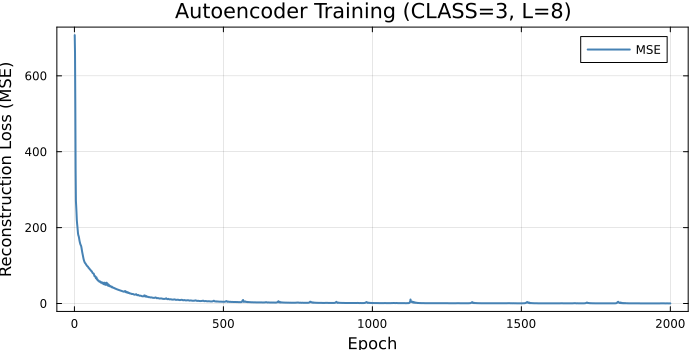

In [15]:
# plot the per-epoch reconstruction loss to check convergence -
let
    plot(losses;
        xlabel="Epoch", ylabel="Reconstruction Loss (MSE)",
        title="Autoencoder Training (CLASS=$(CLASS), L=$(L))",
        label="MSE", color=:steelblue, lw=2,
        framestyle=:box, size=(700, 350))
end

> __What do we observe?__
>
> The loss curve should decrease steeply at first and then flatten as the encoder and decoder settle into a stable compressed representation. It will not reach zero because some reconstruction error is irreducible given the $L = 8$-dimensional bottleneck, but a well-trained model should reduce the loss well below its initial value.
___

## Task 3: Latent Space Analysis

After training, we evaluate what the autoencoder has learned. First, we compare original images to their reconstructions to gauge how much detail the $L = 8$-dimensional bottleneck retains. Then, we test whether the bottleneck is **smooth** by linearly interpolating between two training images in latent space.

> __Reconstruction: originals vs. decoded__
>
> We encode eight training images to their $L = 8$-dimensional bottleneck codes and decode back to pixel space. The top row shows the originals; the bottom row shows the reconstructions. The per-image reconstruction loss (shown in each title) quantifies how much detail is lost through the bottleneck. Some blurring is expected given the 512x compression.

Let's compare the originals and their reconstructions.

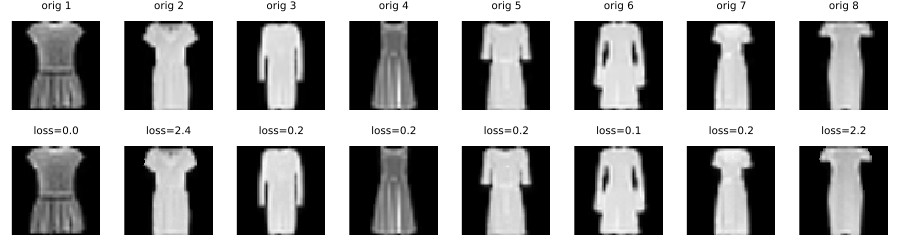

In [16]:
# reconstruction quality: originals (top) vs AE reconstructions (bottom) -
let
    n_show = 8;
    x_orig = X[:, 1:n_show];              # grab the first n_show training images
    z_orig = encode(ae, x_orig);           # compress to bottleneck codes
    x_recon = decode(ae, z_orig);          # reconstruct from codes

    # per-image squared reconstruction error -
    per_image_loss = vec(sum((x_orig .- x_recon).^2; dims=1));

    # build labeled panels: originals on top, reconstructions on bottom -
    plots = [];
    for i in 1:n_show
        img = Gray.(reshape(x_orig[:, i], 64, 64)');
        push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
            title="orig $(i)", titlefontsize=7, aspect_ratio=:equal));
    end
    for i in 1:n_show
        img = Gray.(reshape(x_recon[:, i], 64, 64)');
        push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
            title="loss=$(round(per_image_loss[i], digits=1))", titlefontsize=7, aspect_ratio=:equal));
    end

    plot(plots..., layout=(2, n_show), size=(900, 250))
end

Next, we test whether the encoder has learned a smooth latent space by interpolating between two training images.

> __Latent-space interpolation__
>
> A smooth latent space means that moving along a straight line between two codes $\mathbf{z}_1$ and $\mathbf{z}_2$ produces a coherent sequence of decoded images. We compute $\mathbf{z}_\alpha = (1 - \alpha)\mathbf{z}_1 + \alpha\mathbf{z}_2$ for ten evenly-spaced values of $\alpha \in [0, 1]$ and decode the full path in a single batched call.

Let's encode two images, interpolate between their codes, and display the decoded path.

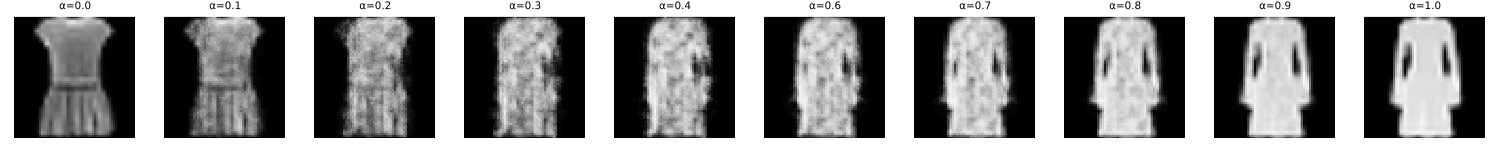

In [17]:
# latent-space interpolation -
n_steps = 10;
x1 = X[:, 1:1];   # first training image  (4096 x 1)
x2 = X[:, 6:6];   # sixth training image  (4096 x 1)

# YOUR CODE HERE
# 1. Encode both images to their bottleneck codes:
#      z1 = encode(ae, x1),  z2 = encode(ae, x2)
# 2. For each alpha in range(0f0, 1f0, length=n_steps):
#      compute z_alpha = (1 - alpha)*z1 + alpha*z2
# 3. Stack all z_alpha into z_path (L x n_steps), then decode:
#      x_path = decode(ae, z_path)
# 4. Display with labeled titles:
#      titles = ["α=$(round(α, digits=1))" for α in alphas]
#      show_image_grid(x_path; nrows=1, ncols=n_steps, titles=titles)

z1 = encode(ae,x1);   # L x 1 bottleneck code for image 1
z2 = encode(ae,x2);   # L x 1 bottleneck code for image 2

alphas = range(0f0, 1f0; length=n_steps);  # evenly spaced blend weights
z_path = hcat([(1f0 - α) .* z1 .+ α .* z2 for α in alphas]...);   # L x n_steps matrix of interpolated codes
x_path = decode(ae,z_path);   # D x n_steps matrix of decoded images

# display the decoded interpolation path with labeled frames -
titles = ["α=$(round(α, digits=1))" for α in alphas];
show_image_grid(x_path; nrows=1, ncols=n_steps, titles=titles)

In [18]:
# ── Autograder: Task 3 ──────────────────────────────────────────────────────
check!(GRADER, "Task 3", "z1 has shape (L, 1)",            1, () -> !ismissing(z1) && size(z1) == (L, 1))
check!(GRADER, "Task 3", "z2 has shape (L, 1)",            1, () -> !ismissing(z2) && size(z2) == (L, 1))
check!(GRADER, "Task 3", "z_path has shape (L, n_steps)",  1, () -> !ismissing(z_path) && size(z_path) == (L, n_steps))
check!(GRADER, "Task 3", "x_path has shape (D, n_steps)",  1, () -> !ismissing(x_path) && size(x_path) == (D, n_steps))

  ✓   1 /  1 pts  z1 has shape (L, 1)
  ✓   1 /  1 pts  z2 has shape (L, 1)
  ✓   1 /  1 pts  z_path has shape (L, n_steps)
  ✓   1 /  1 pts  x_path has shape (D, n_steps)


The autograder checks that `z1`, `z2`, `z_path`, and `x_path` have the expected shapes for the interpolation computation.

___
<a id="discussion"></a>

## Discussion

**DQ1: Reconstruction quality and bottleneck capacity.** The autoencoder compresses each $D = 4096$-pixel image into an $L = 8$-dimensional bottleneck code, a 512× reduction. The encoder must decide what structure to keep and what to discard.

> __Strategy__: Examine the reconstruction panel from Task 3. Are the reconstructions sharp or blurry? Change `L` in the constants block to `2`, `4`, `16`, and `32`, re-run all cells, and compare reconstruction quality across these settings. What fine-grained information appears to be discarded first as the bottleneck shrinks?

Use the strategy above to formulate your answer below.

In [ ]:
# DQ1 scaffold: compare reconstruction quality across bottleneck sizes -
let

    # --- setup ---
    L_values = [2, 4, 8, 16, 32];   # bottleneck dimensions to compare
    n_show = 4;                       # number of sample images per row
    x_sample = X[:, 1:n_show];       # grab the first n_show training images

    # --- first row: plot the original images for reference ---
    plots = [];
    for i in 1:n_show
        img = Gray.(reshape(x_sample[:, i], 64, 64)');  # reshape column to 64x64, convert to Gray
        push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
            title="dress $(i)", titlefontsize=7, aspect_ratio=:equal));
    end

    # --- one row per L value: train/load model, reconstruct, record loss ---
    rows = [];  # accumulator for the summary table
    for L_test in L_values

        # build a fresh model with this bottleneck size -
        ae_test = build_ae_model(D, H, L_test);

        # check if we already trained this model (saved to disk by a previous run) -
        model_path = joinpath(_PATH_TO_DATA, "ae_class$(CLASS)_L$(L_test).jld2");
        if isfile(model_path) == true

            # load the saved weights -
            f = jldopen(model_path, "r");
            Flux.loadmodel!(ae_test, f["model_state"]);
            close(f);
        else

            # no saved model, train from scratch -
            opt = Flux.setup(Adam(LR), ae_test);
            for epoch in 1:NUM_EPOCHS
                loss, grads = Flux.withgradient(ae_test) do m
                    reconstruction_loss(m, X)
                end;
                Flux.update!(opt, ae_test, grads[1]);
            end

            # save for future runs -
            jldsave(model_path; model_state=Flux.state(ae_test), losses=Float32[]);
        end

        # reconstruct the sample images and compute per-image squared error -
        x_hat = decode(ae_test, encode(ae_test, x_sample));
        per_img = vec(sum((x_sample .- x_hat).^2; dims=1));  # one loss value per image

        # record a row for the summary table -
        push!(rows, (L=L_test, dress_1=round(per_img[1], digits=1),
            dress_2=round(per_img[2], digits=1), dress_3=round(per_img[3], digits=1),
            dress_4=round(per_img[4], digits=1), mean=round(mean(per_img), digits=1)));

        # add reconstruction heatmaps to the plot grid (title shows per-image loss) -
        for i in 1:n_show
            img = Gray.(reshape(x_hat[:, i], 64, 64)');
            push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
                title="L=$(L_test) | $(round(per_img[i], digits=1))",
                titlefontsize=7, aspect_ratio=:equal));
        end
    end

    # --- print a summary table of per-image losses ---
    println("Per-image reconstruction loss (sum of squared pixel errors):");
    data = DataFrame(rows);
    pretty_table(data; backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    # --- display the image grid: originals on top, one row per L below ---
    n_rows = 1 + length(L_values);
    plot(plots..., layout=(n_rows, n_show), size=(n_show * 150, n_rows * 140))
end

In [ ]:
#=
Put your answer to DQ1 here.
=#

In [ ]:
did_I_answer_DQ1 = true; # set to `true` after answering DQ1 in the cell above

**DQ2: Latent space smoothness.** Linear interpolation between two bottleneck codes $\mathbf{z}_1$ and $\mathbf{z}_2$ tests whether the autoencoder has learned a smooth, well-structured latent space, or whether nearby codes decode to very different images.

> __Strategy__: Examine the interpolation grid from Task 3. Does the sequence transition smoothly from one image to another, or do intermediate frames look incoherent? Try changing `L` and re-running the interpolation cell. What does a smooth (or fragmented) transition reveal about the geometry of the learned latent space?

Use the strategy above to formulate your answer below.

In [ ]:
# DQ2 scaffold: compare interpolation smoothness across bottleneck sizes -
let

    # --- setup ---
    L_values = [2, 8, 32];                          # bottleneck dimensions to compare
    n_steps = 8;                                     # number of interpolation frames
    x1 = X[:, 1:1];                                 # first endpoint image
    x2 = X[:, 6:6];                                 # second endpoint image
    alphas = range(0f0, 1f0; length=n_steps);        # blend weights from 0 to 1

    # --- one row per L value: load model, interpolate, plot decoded path ---
    plots = [];
    for L_test in L_values

        # load the model trained in DQ1 (must run DQ1 cell first) -
        ae_test = build_ae_model(D, H, L_test);
        model_path = joinpath(_PATH_TO_DATA, "ae_class$(CLASS)_L$(L_test).jld2");
        if isfile(model_path) == true
            f = jldopen(model_path, "r");
            Flux.loadmodel!(ae_test, f["model_state"]);
            close(f);
        end

        # encode both endpoint images to their bottleneck codes -
        z1 = encode(ae_test, x1);  # L_test x 1
        z2 = encode(ae_test, x2);  # L_test x 1

        # walk along the line from z1 to z2 and decode each step -
        for (j, α) in enumerate(alphas)
            z_interp = (1f0 - α) .* z1 .+ α .* z2;  # linear blend at this alpha
            x_hat = decode(ae_test, z_interp);         # decode to pixel space
            img = Gray.(reshape(x_hat, 64, 64)');      # reshape and convert to Gray
            t = (j == 1) ? "L=$(L_test)" : "α=$(round(α, digits=1))";  # label first frame with L
            push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
                title=t, titlefontsize=7, aspect_ratio=:equal));
        end
    end

    # --- display: rows = L values, columns = interpolation steps ---
    plot(plots..., layout=(length(L_values), n_steps),
        size=(n_steps * 120, length(L_values) * 140))
end

In [ ]:
#=
Put your answer to DQ2 here.
=#

In [ ]:
did_I_answer_DQ2 = true; # set to `true` after answering DQ2 in the cell above

**DQ3: Generative limits of the standard autoencoder.** A standard AE places no explicit constraint on the distribution of bottleneck codes. The encoder is free to use any region of $\mathbb{R}^L$ that minimizes reconstruction loss.

> __Strategy__: Run [`extrema(encode(ae, X))`](https://docs.julialang.org/en/v1/base/collections/#Base.extrema) to inspect the range of the learned codes. Then sample `z_rand = randn(Float32, L, 1)` and decode it with [`show_image_grid(decode(ae, z_rand))`](src/Compute.jl). Does the output look like a realistic fashion item? Explain why or why not, and describe what additional constraint would be needed to make the AE a proper generative model.

Use the strategy above to formulate your answer below.

In [ ]:
# DQ3 scaffold: inspect latent code range and decode random samples -
let

    # --- Step 1: encode all training images and report code statistics ---
    Z = encode(ae, X);                    # encode the full training set: L x K
    code_min, code_max = extrema(Z);      # range of learned codes
    @printf("Bottleneck code range: [%.2f, %.2f]\n", code_min, code_max);
    @printf("Code mean: %.2f, code std: %.2f\n", mean(Z), std(Z));
    println("Compare to N(0,1): mean=0.0, std=1.0");

    # --- Step 2: sample random codes from N(0,1) and decode them ---
    n_samples = 8;
    z_rand = randn(Float32, L, n_samples);  # random codes from the standard normal
    x_rand = decode(ae, z_rand);             # decode each random code to pixel space

    # --- Step 3: display the decoded random samples ---
    # if the latent space is not aligned with N(0,1), these will look like noise -
    titles = ["random $(i)" for i in 1:n_samples];
    show_image_grid(x_rand; nrows=1, ncols=n_samples, titles=titles)
end

In [ ]:
#=
Put your answer to DQ3 here.
=#

In [ ]:
did_I_answer_DQ3 = true; # set to `true` after answering DQ3 in the cell above

The autograder checks that each `did_I_answer_DQ*` flag was set to `true`, confirming you wrote a response for each discussion question.

In [ ]:
# ── Autograder: Discussion ────────────────────────────────────────────────────
check!(GRADER, "Discussion", "answered DQ1",   1, () -> did_I_answer_DQ1 == true)
check!(GRADER, "Discussion", "answered DQ2",   1, () -> did_I_answer_DQ2 == true)
check!(GRADER, "Discussion", "answered DQ3",   1, () -> did_I_answer_DQ3 == true)

The final score summarizes all autograder checks and maps the pass/fail counts to a 0-4 rubric where 3 means all tests pass and 4 requires both passing tests and instructor-approved discussion answers.

In [ ]:
# ── Final Score ───────────────────────────────────────────────────────────────
score!(GRADER)

___

## Summary

This problem set builds a deterministic autoencoder for FashionMNIST images and uses reconstruction to study what the bottleneck representation preserves.

> __Key Takeaways__
>
> * **Encoder-decoder structure:** The autoencoder maps each image into a low-dimensional bottleneck code and decodes that code back to pixel space. Training succeeds only if the encoder and decoder work together as a single differentiable model.
> * **Reconstruction loss drives learning:** Mean-squared error compares each input image to its reconstruction and provides the training signal for both networks. The loss curve and reconstruction panel together show whether optimization improved the model.
> * **Latent geometry matters:** Interpolation between two bottleneck codes tests whether nearby latent points decode to related images. A standard autoencoder can reconstruct well without making random latent samples meaningful, which motivates additional constraints in later models.

The same workflow sets up the transition from deterministic autoencoders to variational autoencoders (VAEs), where the latent space is given an explicit probabilistic structure. We'll explore VAEs in the advanced lectures at the end of the course (time permitting).

___